# EDA & Visualization: Employee Attrition

# import

In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("../data/employee_attrition_2026_master.csv")
# df['attrition_pct'] = df['attrition'] * 100
df.head()

,employee_id,age,generation,gender,department,job_level,is_manager,tenure_years,salary_usd,salary_vs_market_pct,...,burnout_score,manager_relationship_score,manager_1on1_per_month,engagement_score,promotions_last_2y,career_growth_score,recent_layoff_round,team_size,attrition_reason,attrition
0,EMP000000,26,Gen Z,Female,Marketing,Junior,0,5.5,70000,5.2,...,3.6,2,0,62,0,2,0,22,stayed,0
1,EMP000001,35,Millennial,Female,Sales,Junior,0,0.5,64000,-15.5,...,4.8,3,2,79,1,2,0,24,stayed,0
2,EMP000002,23,Gen Z,Male,HR,Senior,0,2.0,142000,-15.9,...,10.0,1,2,43,0,4,1,3,poor_management,1
3,EMP000003,20,Gen Z,Female,Sales,Manager,1,2.2,147000,2.6,...,4.3,1,4,64,1,3,0,24,stayed,0
4,EMP000004,40,Millennial,Female,Data,Senior,0,6.0,141000,11.3,...,2.9,1,1,92,0,2,0,5,stayed,0


# checking data

ข้อมูล:45,000แถว   29 คอลัมน์

In [106]:
# ตรวจสอบ Missing Value
print(df.isnull().sum().sum())
df.describe()

0


,age,is_manager,tenure_years,salary_usd,salary_vs_market_pct,rto_mandate,days_in_office_required,commute_minutes,prefers_remote,flexibility_importance,...,after_hours_work,burnout_score,manager_relationship_score,manager_1on1_per_month,engagement_score,promotions_last_2y,career_growth_score,recent_layoff_round,team_size,attrition
count,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,...,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,34.240711,0.242044,3.598353,115385.533333,-1.940573,0.422444,3.000022,35.809444,0.680800,2.994956,...,0.256556,4.820122,2.996000,1.500133,65.723844,0.450867,2.998489,0.236889,13.458911,0.181422
std,8.547373,0.428326,2.545593,50084.707992,9.990708,0.493954,1.578040,25.334550,0.466172,1.415595,...,0.436737,1.964970,1.416469,1.236460,16.718265,0.623320,1.414810,0.425178,6.366689,0.385372
min,20.000000,0.000000,0.100000,35000.000000,-35.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,28.000000,0.000000,1.700000,75000.000000,-8.700000,0.000000,2.000000,17.000000,0.000000,2.000000,...,0.000000,3.400000,2.000000,1.000000,54.000000,0.000000,2.000000,0.000000,8.000000,0.000000
50%,34.000000,0.000000,3.000000,103000.000000,-2.000000,0.000000,3.000000,30.000000,1.000000,3.000000,...,0.000000,4.800000,3.000000,1.000000,66.000000,0.000000,3.000000,0.000000,13.000000,0.000000
75%,40.000000,0.000000,4.800000,146000.000000,4.800000,1.000000,4.000000,48.000000,1.000000,4.000000,...,1.000000,6.200000,4.000000,2.000000,77.000000,1.000000,4.000000,0.000000,19.000000,0.000000
max,64.000000,1.000000,25.000000,345000.000000,35.000000,1.000000,5.000000,180.000000,1.000000,5.000000,...,1.000000,10.000000,5.000000,4.000000,100.000000,2.000000,5.000000,1.000000,24.000000,1.000000


จำนวน Missing Value รวม  0
employee_id ซ้ำ: 0
แถวซ้ำทั้งแถว (ไม่นับ id): 0

In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   employee_id                 45000 non-null  object 
 1   age                         45000 non-null  int64  
 2   generation                  45000 non-null  object 
 3   gender                      45000 non-null  object 
 4   department                  45000 non-null  object 
 5   job_level                   45000 non-null  object 
 6   is_manager                  45000 non-null  int64  
 7   tenure_years                45000 non-null  float64
 8   salary_usd                  45000 non-null  int64  
 9   salary_vs_market_pct        45000 non-null  float64
 10  work_arrangement            45000 non-null  object 
 11  rto_mandate                 45000 non-null  int64  
 12  days_in_office_required     45000 non-null  int64  
 13  commute_minutes             450

###  สัดส่วนพนักงานที่ลาออก (Attrition)

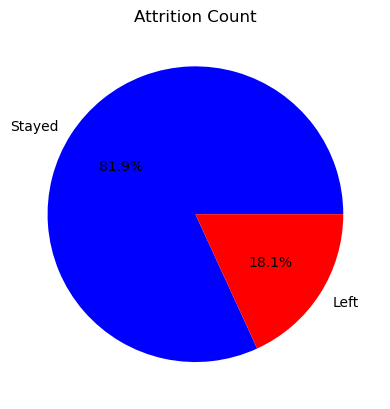

จำนวนพนักงานที่ไม่ลาออก 36836 คน
จำนวนพนักงานที่ลาออก 8164 คน


In [108]:
attr_counts = df['attrition'].value_counts().sort_index()
df['attrition'].value_counts().plot(kind='pie', labels=['Stayed','Left'], colors=['blue','red'], autopct='%1.1f%%')
plt.title("Attrition Count")
plt.ylabel('')
plt.show()
print(f"จำนวนพนักงานที่ไม่ลาออก {attr_counts[0]} คน")
print(f"จำนวนพนักงานที่ลาออก {attr_counts[1]} คน")


**Insight:** พนักงานส่วนใหญ่ยังอยู่ 35,508 คน  81.9% (attrition=0)
มีคนลาออก 7,931 คน 18.1%  (attrition=1)
 เป็นส่วนน้อย ข้อมูลจึงไม่สมดุล (imbalanced)

###  เหตุผลที่ลาออก 

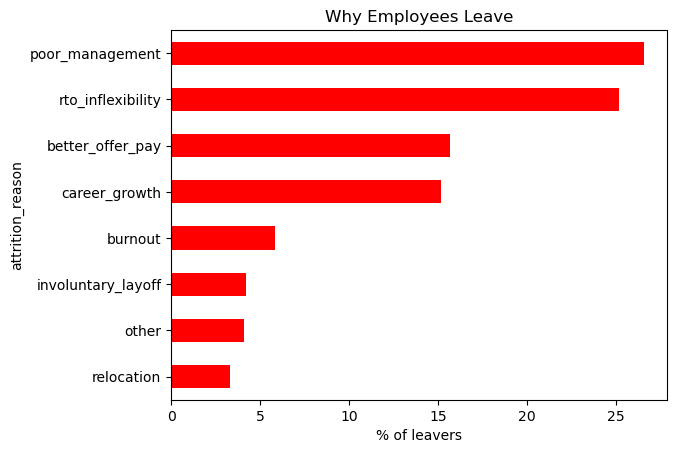

In [109]:
reason = df[df['attrition'] == 1]['attrition_reason'].value_counts(normalize=True) * 100
reason.sort_values().plot(kind='barh', color='r')
plt.xlabel('% of leavers')
plt.title('Why Employees Leave')
plt.show()

**Insight**
- เหตุผลอันดับ 1 คือ การจัดการแย่ 26.5% และอันดับ 2 ความไม่ยืดหยุ่น 25.1% 
- และค่าตอบแทนที่ดีกว่า (15.7%) และการเติบโตในสายงาน (15.2%)
- หมดไฟ (5.8%), ถูกเลิกจ้าง (4.2%), อื่น ๆ (4.1%), ย้ายที่อยู่ (3.3%) เป็นสาเหตุรอง
- สาเหตุหลัก 4 อันดับแรก (82%) เป็นสิ่งที่องค์กร จัดการได้ ไม่ใช่ปัจจัยภายนอก

In [110]:
df.corr

<bound method DataFrame.corr of       employee_id  age  generation  gender   department job_level  is_manager  \
0       EMP000000   26       Gen Z  Female    Marketing    Junior           0   
1       EMP000001   35  Millennial  Female        Sales    Junior           0   
2       EMP000002   23       Gen Z    Male           HR    Senior           0   
3       EMP000003   20       Gen Z  Female        Sales   Manager           1   
4       EMP000004   40  Millennial  Female         Data    Senior           0   
...           ...  ...         ...     ...          ...       ...         ...   
44995   EMP044995   42  Millennial   Other  Engineering       Mid           0   
44996   EMP044996   46       Gen X  Female         Data   Manager           1   
44997   EMP044997   30  Millennial  Female  Engineering       Mid           0   
44998   EMP044998   23       Gen Z  Female  Engineering       Mid           0   
44999   EMP044999   30  Millennial  Female  Engineering    Senior           0

### Correlation bar chart

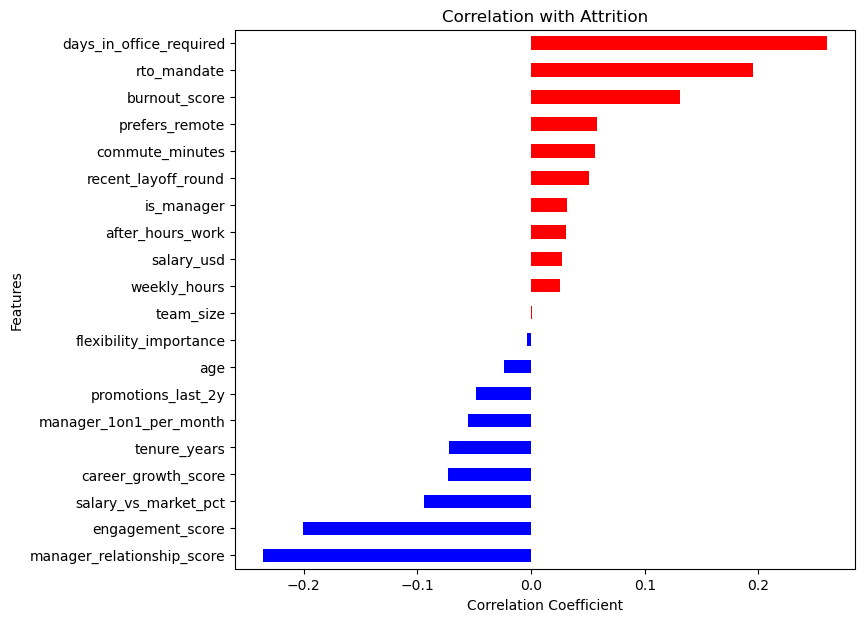

In [111]:
corr_target = df.corr(numeric_only=True)['attrition'].drop('attrition').sort_values()
corr_target.plot(kind='barh', figsize=(8,7), color=['red' if v>0 else 'blue' for v in corr_target] )
plt.title("Correlation with Attrition")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")

plt.show()

**Insight** 
จากกราฟแสดงได้ว่า ปัจจัยที่ส่งผลต่อการลาออกของพนักงานแบ่งออกเป็น

แท่งสีแดง = ตัวแปรที่ยิ่งสูงยิ่งลาออกเยอะ เช่น work_arrangement_onsite, burnout_score  
แท่งสีน้ำเงิน = ตัวแปรที่ยิ่งสูงยิ่งลาออกน้อย เช่น manager_relationship_score, engagement_score


### กราฟกลุ่มที่อัตราลาออกสูงสุด 5 อันดับแรก

### 1.days_in_office_required (วันที่ต้องอยู่ในออฟฟิศ) กับ Attrition

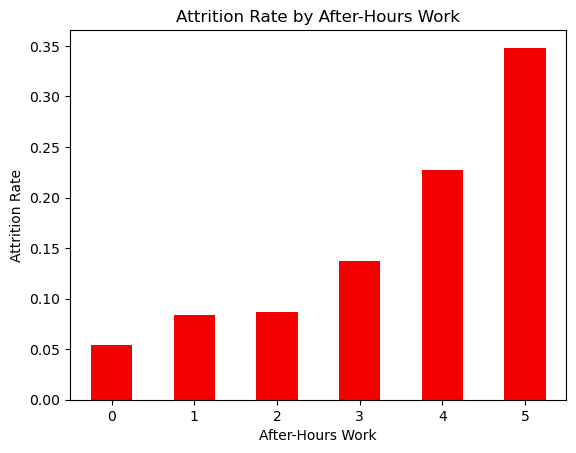

In [112]:
df.groupby('days_in_office_required')['attrition'].mean().plot(kind='bar', color="#F30000")
plt.title("Attrition Rate by After-Hours Work")
plt.xticks(rotation=0)
plt.xlabel("After-Hours Work")
plt.ylabel("Attrition Rate")
plt.show()

**Insight:** 

### 2. rto_mandate  (  ) กับ Attrition

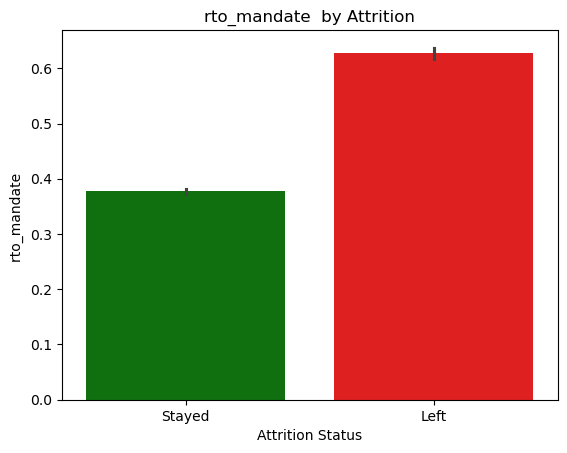

In [113]:
sns.barplot(x='attrition', y='rto_mandate', data=df, hue='attrition', palette=['green','red'], legend=False)

plt.title("rto_mandate  by Attrition")
plt.xticks([0, 1], ["Stayed", "Left"])
plt.xlabel("Attrition Status")
plt.ylabel("rto_mandate ")
plt.show()

**Insight:** 

### 5. Work Arrangement กับ Attrition

In [114]:
df['work_arrangement'] = np.select(
    [df['work_arrangement_onsite'], df['work_arrangement_remote']],
    ['onsite', 'remote'],
    default='hybrid'
)

df.groupby('work_arrangement')['attrition'].mean().plot(kind='bar', color=['orange','green','blue'])

plt.title("Attrition Rate by Work Arrangement")
plt.xlabel("Work Arrangement")
plt.xticks(rotation=0)
plt.ylabel("Attrition Rate (%)")
plt.show()

KeyError: 'work_arrangement_onsite'

**Insight:** พนักงานที่ทำงาน onsite มีอัตราการลาออกสูงกว่าคนที่ทำงาน hybrid, remote ชัดเจน

### 6.Tenure (อายุงาน) กับ Attrition 

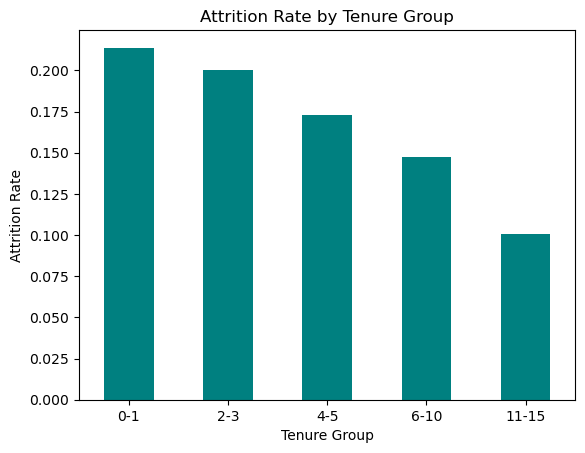

In [ ]:
df['tenure_bin'] = pd.cut(df['tenure_years'], bins=[0,1,3,5,10,15],labels=['0-1','2-3','4-5','6-10','11-15'])
df.groupby(df['tenure_bin'], observed=True)['attrition'].mean().plot(kind='bar', color='teal')
plt.title("Attrition Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Attrition Rate")
plt.xticks(rotation=0)
plt.show()

**Insight:** ดูจากช่วยอายุ กลุ่มที่มีอายุงานน้อย มีอัตราการลาออกสูงกว่ากลุ่มคนที่่อายุงานหลายปี

### 7. ค่าตอบแทน Salary vs Market กับ Attrition

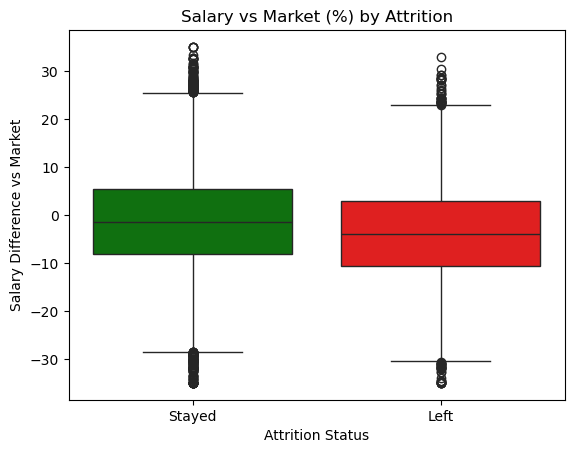

In [ ]:
sns.boxplot(x='attrition', y='salary_vs_market_pct', data=df, hue='attrition', palette=['green','red'], legend=False)
plt.title("Salary vs Market (%) by Attrition")
plt.xticks([0, 1], ["Stayed", "Left"])
plt.xlabel("Attrition Status")
plt.ylabel("Salary Difference vs Market")
plt.show()

**Insight:** กลุ่มที่ลาออก มีค่าเงินเดือนเทียบตลาด ต่ำกว่ากลุ่มที่อยู่ต่อ คนที่ได้เงินเดือนต่ำกว่าตลาดมาก มีอัตราลาออกสูงกว่าคนที่ได้เงินเดือนสูงกว่าตลาด

### 8. After-Hours Work  (การทำงานนอกเวลา) กับ Attrition

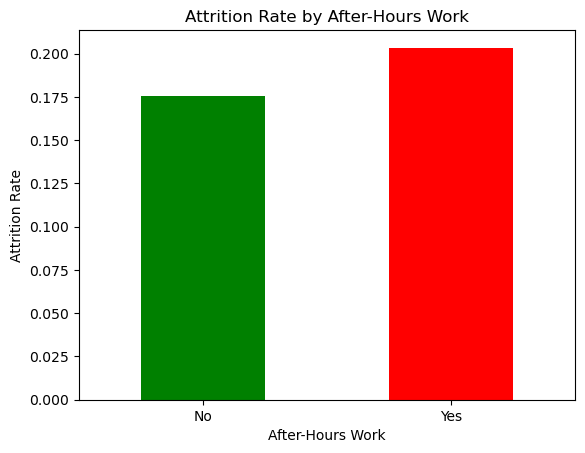

In [ ]:
df.groupby('after_hours_work')['attrition'].mean().plot(kind='bar', color=['green','red'])
plt.title("Attrition Rate by After-Hours Work")
plt.xticks([0, 1], ["No", "Yes"], rotation=0)
plt.xlabel("After-Hours Work")
plt.ylabel("Attrition Rate")
plt.show()

**Insight:** พนักงานที่ต้องทำงานนอกเวลาเป็นประจำมีอัตราลาออกสูงกว่าคนที่ไม่ต้องทำงานนอกเวลา  ทำให้เห็นว่า การทำงานนอกเวลา ที่แย่ลงมีผลผลักดันให้ลาออกมากขึ้น 

### 9.  Commute (การเดินทาง) กับ Attrition

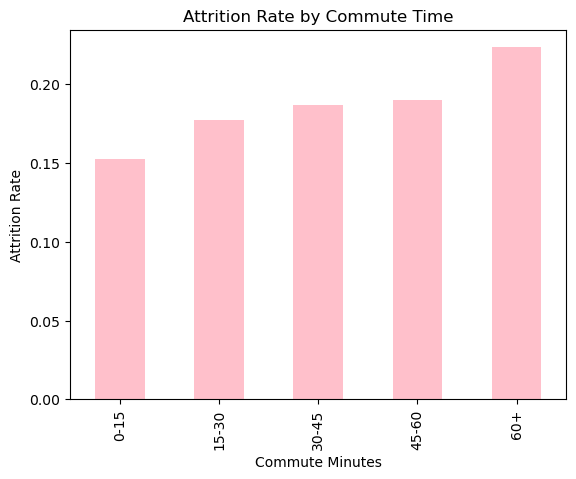

In [ ]:
df['commute_bin'] = pd.cut(df['commute_minutes'], bins=[0,15,30,45,60,200],labels=['0-15','15-30','30-45','45-60','60+'])
df.groupby('commute_bin', observed=True)['attrition'].mean().plot(kind='bar', color='pink')
plt.title("Attrition Rate by Commute Time")
plt.ylabel("Attrition Rate")
plt.xlabel("Commute Minutes")
plt.show()

**Insight:** อัตราลาออกเพิ่มขึ้นตามช่วงเวลาเดินทาง กลุ่มที่เดินทางเกิน 60 นาทีมีอัตราลาออกสูงสุด เมื่อเทียบกับกลุ่มที่เดินทางไม่เกิน 15 นาที

In [ ]:
df.corr(numeric_only=True)['attrition'].sort_values()

manager_relationship_score   -0.234950
engagement_score             -0.200512
work_arrangement_remote      -0.111377
salary_vs_market_pct         -0.093825
career_growth_score          -0.073622
tenure_years                 -0.069007
ai_tools_adoption            -0.065442
manager_1on1_per_month       -0.056266
promotions_last_2y           -0.048093
age                          -0.029241
gender_Male                  -0.023914
gender_Other                 -0.008980
department_Sales             -0.006955
department_Operations        -0.005896
department_Finance           -0.003542
flexibility_importance       -0.003223
department_HR                -0.001791
team_size                     0.000630
department_Marketing          0.001017
department_Data               0.003866
department_Engineering        0.005315
department_Product            0.005457
weekly_hours                  0.024927
salary_usd                    0.027727
job_level                     0.029175
after_hours_work         

## สรุปผล EDA

**ปัจจัยที่สัมพันธ์กับ Attrition**

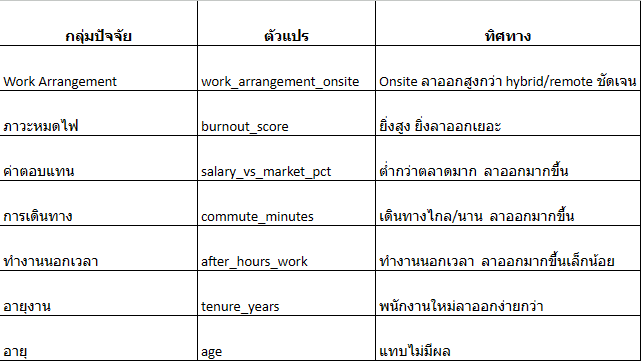
